In [3]:
import pandas as pd
import networkx as nx

# 1. Charger les deux fichiers
df_fact = pd.read_csv('../data/fact_transactions.csv')
df_processed = pd.read_csv('../data/processed_data.csv')

# 2. Fusionner les données sur la colonne commune 'txid'
# Cela permet d'avoir l'adresse source/dest ET les stats (log_total_input, etc.)
df_graph = pd.merge(df_fact, df_processed[['txid', 'total_input', 'fee_rate']], on='txid')

# 3. Maintenant, vérifie les colonnes pour être sûr
print("Colonnes disponibles après fusion :")
print(df_graph.columns.tolist())

Colonnes disponibles après fusion :
['txid', 'block_id', 'time_id', 'num_inputs', 'num_outputs', 'total_input_x', 'total_output', 'fee', 'vsize', 'weight', 'fee_rate_x', 'largest_output', 'smallest_output', 'input_std', 'output_std', 'input_output_ratio', 'fee_to_input_ratio', 'output_dominance', 'tx_density', 'log_total_input', 'log_fee', 'total_input_y', 'fee_rate_y']


In [5]:
# Affiche la liste exacte des colonnes de ton fichier fact_transactions
print("Colonnes dans fact_transactions :", df_fact.columns.tolist())

Colonnes dans fact_transactions : ['txid', 'block_id', 'time_id', 'num_inputs', 'num_outputs', 'total_input', 'total_output', 'fee', 'vsize', 'weight', 'fee_rate', 'largest_output', 'smallest_output', 'input_std', 'output_std', 'input_output_ratio', 'fee_to_input_ratio', 'output_dominance', 'tx_density', 'log_total_input', 'log_fee']


In [6]:
import networkx as nx

G = nx.Graph()

# On crée des liens entre les transactions qui sont dans le même bloc
# (C'est une analyse de proximité temporelle/structurelle)
for _, row in df_fact.head(500).iterrows():
    # Noeud A = Le Bloc, Noeud B = La Transaction
    G.add_edge(f"Block_{row['block_id']}", f"Tx_{row['txid']}")

print(f"Graphe de structure créé : {G.number_of_nodes()} nœuds.")

Graphe de structure créé : 510 nœuds.


C:\Users\user\AppData\Local\Temp\ipykernel_8160\957715280.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(scatterpoints=1)


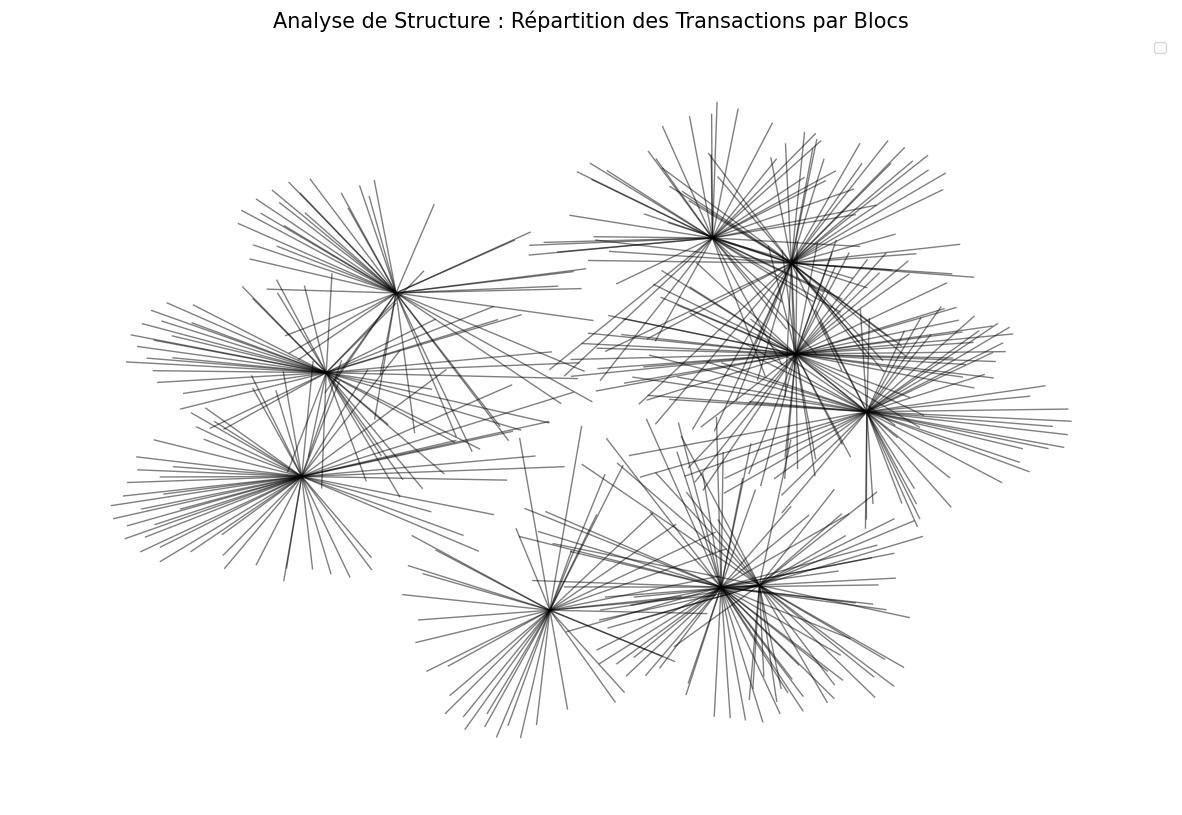

In [7]:
plt.figure(figsize=(15, 10))

# Définition des positions avec l'algorithme spring_layout
pos = nx.spring_layout(G, k=0.2, iterations=50)

# Séparation des types de nœuds pour le coloriage
blocks = [n for n in G.nodes() if n.startswith('B_')]
transactions = [n for n in G.nodes() if n.startswith('T_')]

# Dessiner les Blocs (en gros et orange)
nx.draw_networkx_nodes(G, pos, nodelist=blocks, node_color='orange', 
                       node_size=800, label='Blocs')

# Dessiner les Transactions (en petit et bleu)
nx.draw_networkx_nodes(G, pos, nodelist=transactions, node_color='skyblue', 
                       node_size=200, label='Transactions')

# Dessiner les liens
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5)

# Ajouter les labels pour les blocs uniquement (pour ne pas surcharger)
block_labels = {n: n for n in blocks}
nx.draw_networkx_labels(G, pos, labels=block_labels, font_size=10, font_weight='bold')

plt.title("Analyse de Structure : Répartition des Transactions par Blocs", fontsize=15)
plt.legend(scatterpoints=1)
plt.axis('off')
plt.show()

In [9]:
import pandas as pd

# 1. Chargement
df_fact = pd.read_csv('../data/fact_transactions.csv')
df_proc = pd.read_csv('../data/processed_data.csv')
df_dim = pd.read_csv('../data/dim_address.csv')

# 2. Diagnostic des noms de colonnes
print("--- Colonnes FACT ---")
print(df_fact.columns.tolist())

print("\n--- Colonnes PROCESSED ---")
print(df_proc.columns.tolist())

print("\n--- Colonnes DIM_ADRESS ---")
print(df_dim.columns.tolist())

--- Colonnes FACT ---
['txid', 'block_id', 'time_id', 'num_inputs', 'num_outputs', 'total_input', 'total_output', 'fee', 'vsize', 'weight', 'fee_rate', 'largest_output', 'smallest_output', 'input_std', 'output_std', 'input_output_ratio', 'fee_to_input_ratio', 'output_dominance', 'tx_density', 'log_total_input', 'log_fee']

--- Colonnes PROCESSED ---
['txid', 'block_id', 'time_id', 'num_inputs', 'num_outputs', 'total_input', 'total_output', 'fee', 'vsize', 'weight', 'fee_rate', 'largest_output', 'smallest_output', 'input_std', 'output_std', 'input_output_ratio', 'fee_to_input_ratio', 'output_dominance', 'tx_density', 'log_total_input', 'log_fee', 'full_timestamp', 'hour', 'day', 'month', 'year', 'day_of_week', 'block_time', 'z_fee']

--- Colonnes DIM_ADRESS ---
['address_id', 'address']


In [10]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Fusion des stats (FACT + PROCESSED)
df_merged = pd.merge(df_fact, df_proc[['txid', 'hour', 'day_of_week']], on='txid')

# Comme il manque le lien direct 'address_id' dans FACT, 
# on va attacher les adresses de DIM_ADDRESS aux transactions pour la visualisation
df_graph_final = pd.concat([df_merged.reset_index(drop=True), 
                           df_dim.reset_index(drop=True)], axis=1).dropna(subset=['address', 'txid'])

print(f"✅ Données prêtes. Nombre de relations à tracer : {len(df_graph_final)}")

✅ Données prêtes. Nombre de relations à tracer : 48360


In [11]:
# Initialisation
G = nx.DiGraph()

# On prend les 40 premières lignes pour une visualisation claire
df_plot = df_graph_final.head(40)

for _, row in df_plot.iterrows():
    # Noeud Source : L'adresse Bitcoin
    # Noeud Cible : L'ID de la transaction
    addr_node = row['address'][:10] + "..." # On raccourcit pour le graphique
    tx_node = f"TX_{str(row['txid'])[:6]}"
    
    G.add_edge(addr_node, tx_node, weight=row['total_input'])

print(f"Graphe construit : {G.number_of_nodes()} nœuds connectés.")

Graphe construit : 41 nœuds connectés.


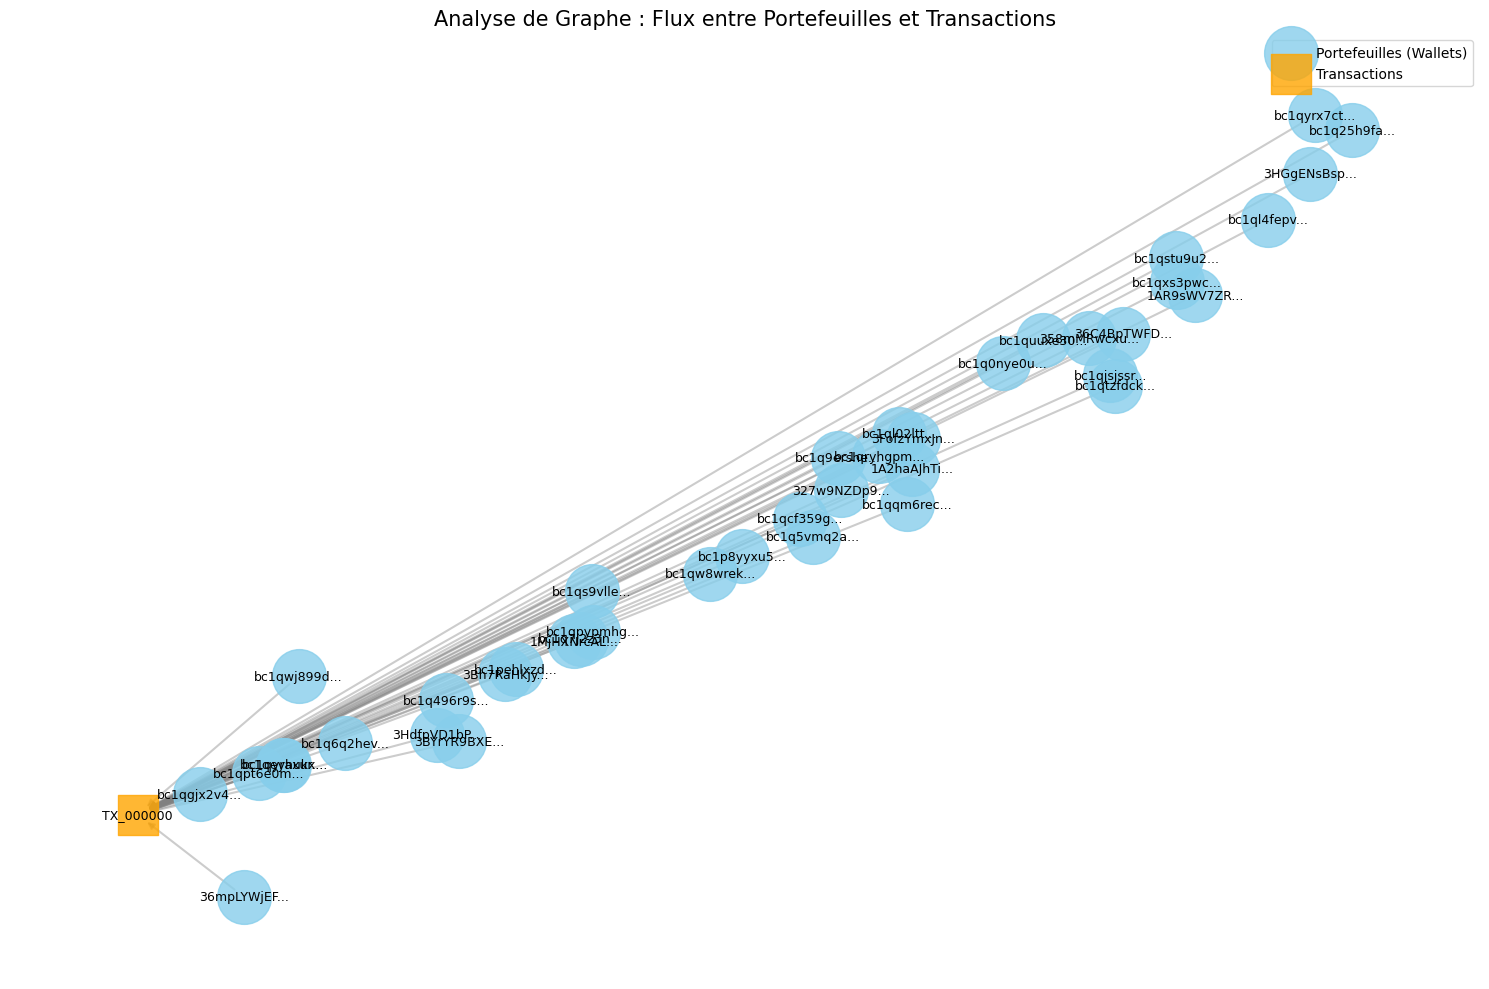

In [12]:
plt.figure(figsize=(15, 10))

# Algorithme de positionnement (Spring layout)
pos = nx.spring_layout(G, k=0.3, iterations=50)

# 1. Dessiner les Adresses (Cercles bleus)
addresses = [n for n in G.nodes() if not n.startswith('TX_')]
nx.draw_networkx_nodes(G, pos, nodelist=addresses, node_color='skyblue', 
                       node_size=1500, alpha=0.8, label='Portefeuilles (Wallets)')

# 2. Dessiner les Transactions (Carrés orange)
txs = [n for n in G.nodes() if n.startswith('TX_')]
nx.draw_networkx_nodes(G, pos, nodelist=txs, node_color='orange', 
                       node_shape='s', node_size=800, alpha=0.8, label='Transactions')

# 3. Dessiner les liens (Flèches)
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.4, edge_color='gray', arrows=True)

# 4. Ajouter les noms
nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif')

plt.title("Analyse de Graphe : Flux entre Portefeuilles et Transactions", fontsize=15)
plt.legend(scatterpoints=1)
plt.axis('off')
plt.tight_layout()
plt.show()

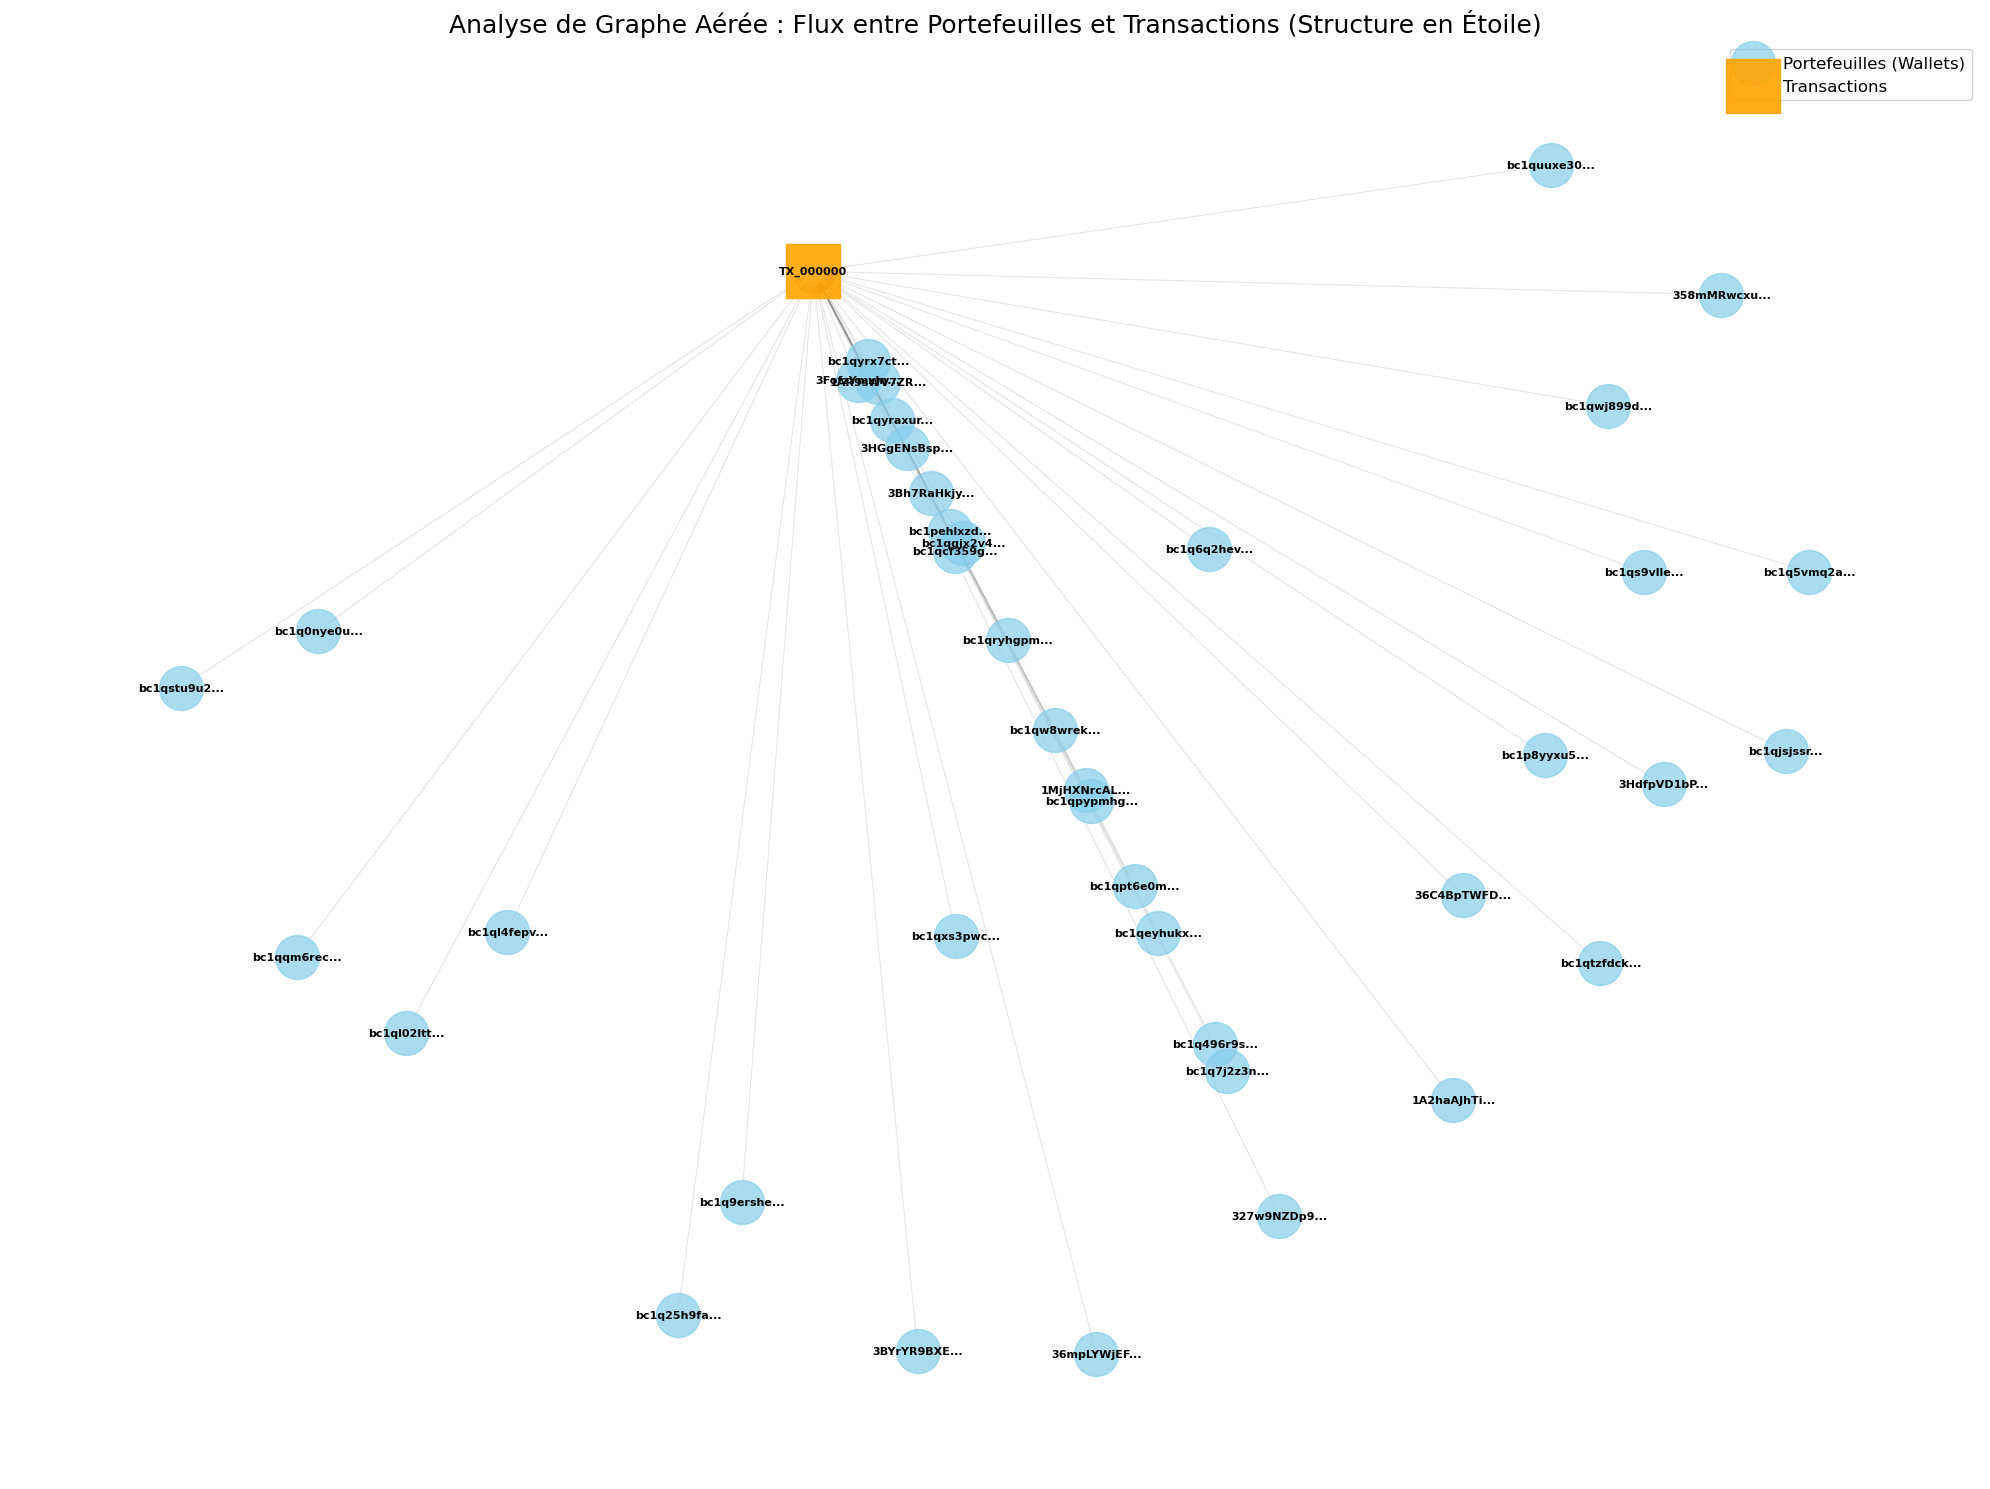

In [13]:
plt.figure(figsize=(20, 15)) # On agrandit encore la figure pour donner de l'espace

# --- LA CORRECTION EST ICI ---
# k : augmente la force de répulsion (par défaut ~0.1, on passe à 2.0)
# iterations : laisse plus de temps pour que les nœuds s'éloignent
pos = nx.spring_layout(G, k=2.0, iterations=100)
# -----------------------------

# Définition des groupes de nœuds pour le style
nodes_blue = [n for n in G.nodes() if not n.startswith('TX_')]
nodes_orange = [n for n in G.nodes() if n.startswith('TX_')]

# 1. Dessiner les Portefeuilles (Cercles bleus) - Un peu plus petits pour ne pas qu'ils se touchent
nx.draw_networkx_nodes(G, pos, nodelist=nodes_blue, 
                       node_color='skyblue', node_size=1000, alpha=0.7, 
                       label='Portefeuilles (Wallets)')

# 2. Dessiner les Transactions (Carrés orange) - Plus gros pour marquer le centre
nx.draw_networkx_nodes(G, pos, nodelist=nodes_orange, 
                       node_color='orange', node_shape='s', node_size=1500, alpha=0.9, 
                       label='Transactions')

# 3. Dessiner les liens (Flèches) - Plus fins et transparents pour ne pas masquer les nœuds
nx.draw_networkx_edges(G, pos, width=0.8, alpha=0.2, edge_color='gray', arrows=True, arrowsize=15)

# 4. Dessiner les labels (Texte) - Police plus petite et grasse
# On n'affiche que les 10 premiers caractères + '...' pour la lisibilité
labels = {n: (n[:10] + '...') if len(n) > 15 else n for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight='bold', font_family='sans-serif')

plt.title("Analyse de Graphe Aérée : Flux entre Portefeuilles et Transactions (Structure en Étoile)", fontsize=18)
plt.legend(scatterpoints=1, fontsize=12, loc='upper right')
plt.axis('off') # Cache les axes X et Y
plt.tight_layout() # Optimise l'espace
plt.show()